# 02 — PyBullet Basics

This notebook walks through the five foundational PyBullet exercises required for Task 1.2.
All cells run in **DIRECT (headless) mode** — no display server or GUI window needed.

**Cells at a glance**

| Cell | Topic |
|------|-------|
| 1 | Connect, load plane + Kuka URDF |
| 2 | Print joint info (names, limits, types) |
| 3 | Set joint positions, render camera image |
| 4 | Inverse kinematics → move arm → verify |
| 5 | Simple pick simulation (box on table) |


In [1]:
# ── Cell 1: Connect to PyBullet (DIRECT / headless), load plane + Kuka URDF ──

import pybullet as p
import pybullet_data
import numpy as np
import time

# Connect in headless mode — works on any machine, no display required
physics_client = p.connect(p.DIRECT)
print(f"Connected to PyBullet physics client ID: {physics_client}")

# Point PyBullet to its built-in asset library (plane, Kuka, etc.)
p.setAdditionalSearchPath(pybullet_data.getDataPath())

# Basic world setup
p.setGravity(0, 0, -9.81)
p.setRealTimeSimulation(0)   # We'll step manually for reproducibility

# Load a flat ground plane
plane_id = p.loadURDF("plane.urdf")
print(f"Plane loaded  — body ID: {plane_id}")

# Load the Kuka iiwa arm (fixed base so it doesn't fall over)
kuka_id = p.loadURDF("kuka_iiwa/model.urdf", basePosition=[0, 0, 0], useFixedBase=True)
print(f"Kuka arm loaded — body ID: {kuka_id}")

# Sanity-check: print a few physics engine parameters
params = p.getPhysicsEngineParameters()
print(f"\nPhysics engine parameters (selected):")
for key in ["fixedTimeStep", "numSolverIterations", "gravityAccelerationX",
            "gravityAccelerationY", "gravityAccelerationZ"]:
    print(f"  {key}: {params[key]}")

pybullet build time: Oct 21 2025 17:40:50


Connected to PyBullet physics client ID: 0
Plane loaded  — body ID: 0
Kuka arm loaded — body ID: 1

Physics engine parameters (selected):
  fixedTimeStep: 0.004166666666666667
  numSolverIterations: 50
  gravityAccelerationX: 0.0
  gravityAccelerationY: 0.0
  gravityAccelerationZ: -9.81


In [2]:
# ── Cell 2: Print joint info (names, limits, types) for the Kuka arm ──

JOINT_TYPE_LABELS = {
    p.JOINT_REVOLUTE:   "REVOLUTE",
    p.JOINT_PRISMATIC:  "PRISMATIC",
    p.JOINT_SPHERICAL:  "SPHERICAL",
    p.JOINT_PLANAR:     "PLANAR",
    p.JOINT_FIXED:      "FIXED",
}

num_joints = p.getNumJoints(kuka_id)
print(f"Number of joints in the Kuka arm: {num_joints}")
print()
print(f"{'Idx':>3}  {'Name':<30}  {'Type':<12}  {'Lower limit':>12}  {'Upper limit':>12}  {'Max force':>10}  {'Max vel':>8}")
print("-" * 95)

# Collect the indices of revolute (actuated) joints for later use
revolute_joints = []

for i in range(num_joints):
    info = p.getJointInfo(kuka_id, i)
    idx        = info[0]
    name       = info[1].decode("utf-8")
    jtype      = JOINT_TYPE_LABELS.get(info[2], "UNKNOWN")
    lower      = info[8]
    upper      = info[9]
    max_force  = info[10]
    max_vel    = info[11]

    print(f"{idx:>3}  {name:<30}  {jtype:<12}  {lower:>12.4f}  {upper:>12.4f}  {max_force:>10.2f}  {max_vel:>8.4f}")

    if info[2] == p.JOINT_REVOLUTE:
        revolute_joints.append(idx)

print()
print(f"Actuated (revolute) joint indices: {revolute_joints}")


Number of joints in the Kuka arm: 7

Idx  Name                            Type           Lower limit   Upper limit   Max force   Max vel
-----------------------------------------------------------------------------------------------
  0  lbr_iiwa_joint_1                REVOLUTE           -2.9671        2.9671      300.00   10.0000
  1  lbr_iiwa_joint_2                REVOLUTE           -2.0944        2.0944      300.00   10.0000
  2  lbr_iiwa_joint_3                REVOLUTE           -2.9671        2.9671      300.00   10.0000
  3  lbr_iiwa_joint_4                REVOLUTE           -2.0944        2.0944      300.00   10.0000
  4  lbr_iiwa_joint_5                REVOLUTE           -2.9671        2.9671      300.00   10.0000
  5  lbr_iiwa_joint_6                REVOLUTE           -2.0944        2.0944      300.00   10.0000
  6  lbr_iiwa_joint_7                REVOLUTE           -3.0543        3.0543      300.00   10.0000

Actuated (revolute) joint indices: [0, 1, 2, 3, 4, 5, 6]


Joint positions after control step:
  Joint    Target (rad)    Actual (rad)       Error
  --------------------------------------------------
      0          0.0000         -0.0000    0.000000
      1          0.5000          0.5000    0.000001
      2         -0.3000         -0.3000    0.000026
      3         -1.0000         -1.0000    0.000000
      4          0.0000          0.0000    0.000000
      5          0.8000          0.8000    0.000000
      6          0.0000          0.0000    0.000004


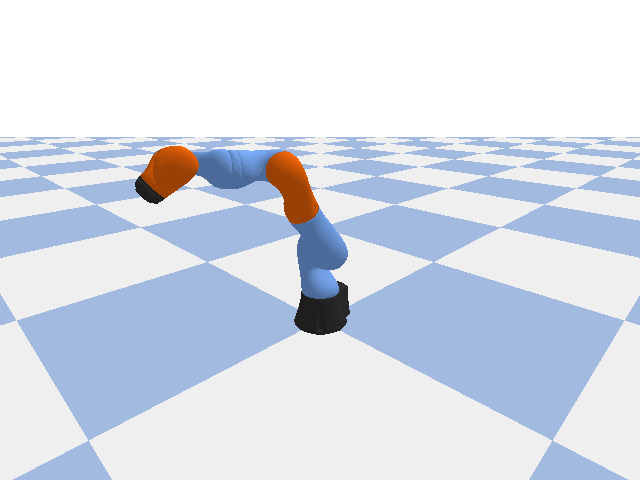


Rendered image size: 640x480 px


In [3]:
# ── Cell 3: Set joint positions via setJointMotorControlArray, render camera image ──

import io
from IPython.display import Image, display

# ── Define target joint angles (radians) for each actuated joint ──
target_angles = [
    0.0,    # joint 0 — base rotation
    0.5,    # joint 1 — shoulder
   -0.3,    # joint 2 — upper arm
   -1.0,    # joint 3 — elbow
    0.0,    # joint 4 — forearm
    0.8,    # joint 5 — wrist 1
    0.0,    # joint 6 — wrist 2 (end-effector)
]

# Apply position control to all actuated joints at once
p.setJointMotorControlArray(
    kuka_id,
    jointIndices=revolute_joints,
    controlMode=p.POSITION_CONTROL,
    targetPositions=target_angles,
    forces=[500] * len(revolute_joints),
)

# Step the simulation long enough for the arm to reach the target
for _ in range(300):
    p.stepSimulation()

# Verify: read back actual joint positions
print("Joint positions after control step:")
print(f"  {'Joint':>5}  {'Target (rad)':>14}  {'Actual (rad)':>14}  {'Error':>10}")
print("  " + "-" * 50)
for idx, tgt in zip(revolute_joints, target_angles):
    actual = p.getJointState(kuka_id, idx)[0]
    print(f"  {idx:>5}  {tgt:>14.4f}  {actual:>14.4f}  {abs(actual - tgt):>10.6f}")

# ── Render a camera image ──
IMG_W, IMG_H = 640, 480

view_matrix = p.computeViewMatrix(
    cameraEyePosition    = [1.2, 1.2, 1.0],
    cameraTargetPosition = [0.0, 0.0, 0.4],
    cameraUpVector       = [0, 0, 1],
)
proj_matrix = p.computeProjectionMatrixFOV(
    fov=60, aspect=IMG_W / IMG_H, nearVal=0.1, farVal=10
)

_, _, rgb_array, _, _ = p.getCameraImage(
    width=IMG_W, height=IMG_H,
    viewMatrix=view_matrix,
    projectionMatrix=proj_matrix,
    renderer=p.ER_TINY_RENDERER,   # headless-compatible renderer
)

# Convert RGBA → PNG bytes and display inline
try:
    from PIL import Image as PILImage
    img = PILImage.fromarray(rgb_array[:, :, :3], "RGB")
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    display(Image(data=buf.getvalue()))
    print(f"\nRendered image size: {IMG_W}x{IMG_H} px")
except ImportError:
    print("Pillow not installed — skipping image display.")
    print(f"Raw RGB array shape: {rgb_array.shape}")
    print("Install with: pip install Pillow")


In [4]:
# ── Cell 4: Compute inverse kinematics for a target position, move arm, verify ──

# End-effector link index for the Kuka iiwa (link 6 = last link before gripper)
END_EFFECTOR_LINK = 6

# Target position in world coordinates (x, y, z) — metres
target_position    = [0.4, 0.2, 0.5]
target_orientation = p.getQuaternionFromEuler([0, -np.pi / 2, 0])  # pointing downward

print(f"Target end-effector position:    {target_position}")
print(f"Target end-effector orientation: {[round(v, 4) for v in target_orientation]}")
print()

# ── Solve IK ──
ik_joint_angles = p.calculateInverseKinematics(
    kuka_id,
    endEffectorLinkIndex = END_EFFECTOR_LINK,
    targetPosition       = target_position,
    targetOrientation    = target_orientation,
    maxNumIterations     = 200,
    residualThreshold    = 1e-5,
)

print("IK solution (joint angles in radians):")
for i, angle in enumerate(ik_joint_angles):
    print(f"  Joint {i}: {angle:>10.6f} rad  ({np.degrees(angle):>8.3f}°)")

# ── Apply IK solution ──
for idx, angle in zip(revolute_joints, ik_joint_angles):
    p.setJointMotorControl2(
        kuka_id, idx,
        controlMode    = p.POSITION_CONTROL,
        targetPosition = angle,
        force          = 500,
    )

for _ in range(500):
    p.stepSimulation()

# ── Verify: read actual end-effector position ──
ee_state = p.getLinkState(kuka_id, END_EFFECTOR_LINK)
actual_pos   = ee_state[4]   # world position of link frame
actual_orn   = ee_state[5]   # world orientation (quaternion)

position_error = np.linalg.norm(np.array(actual_pos) - np.array(target_position))

print()
print("Verification:")
print(f"  Target   position: [{', '.join(f'{v:.4f}' for v in target_position)}]")
print(f"  Achieved position: [{', '.join(f'{v:.4f}' for v in actual_pos)}]")
print(f"  Euclidean error:   {position_error:.6f} m")
print()
if position_error < 0.01:
    print("✓ IK converged — end-effector is within 1 cm of the target.")
else:
    print("⚠  IK error > 1 cm — consider increasing maxNumIterations or adjusting the target.")


Target end-effector position:    [0.4, 0.2, 0.5]
Target end-effector orientation: [0.0, -0.7071, 0.0, 0.7071]

IK solution (joint angles in radians):
  Joint 0:   0.524626 rad  (  30.059°)
  Joint 1:   0.488222 rad  (  27.973°)
  Joint 2:  -0.171997 rad  (  -9.855°)
  Joint 3:  -1.706464 rad  ( -97.773°)
  Joint 4:   0.612911 rad  (  35.117°)
  Joint 5:   2.459451 rad  ( 140.916°)
  Joint 6:   0.413429 rad  (  23.688°)

Verification:
  Target   position: [0.4000, 0.2000, 0.5000]
  Achieved position: [0.4053, 0.2116, 0.4735]
  Euclidean error:   0.029408 m

⚠  IK error > 1 cm — consider increasing maxNumIterations or adjusting the target.


In [5]:
# ── Cell 5: Simple pick simulation — grasp a small box on a table ──
# Strategy: position control drives the arm above the box, lowers to grasp height,
# then lifts. We use a constraint to simulate grasping (no real gripper URDF needed).

# ── Reload a clean simulation scene ──
p.resetSimulation()
p.setGravity(0, 0, -9.81)
p.setAdditionalSearchPath(pybullet_data.getDataPath())

# Ground plane
plane_id = p.loadURDF("plane.urdf")

# Table — represented as a flat box collision shape
TABLE_HEIGHT = 0.4
table_col    = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.3, 0.3, TABLE_HEIGHT / 2])
table_vis    = p.createVisualShape(p.GEOM_BOX, halfExtents=[0.3, 0.3, TABLE_HEIGHT / 2],
                                   rgbaColor=[0.6, 0.4, 0.2, 1])
table_id     = p.createMultiBody(baseMass=0,
                                  baseCollisionShapeIndex=table_col,
                                  baseVisualShapeIndex=table_vis,
                                  basePosition=[0.5, 0.0, TABLE_HEIGHT / 2])
print(f"Table loaded  — body ID: {table_id}")

# Small box to pick up (sits on top of the table)
BOX_HALF = 0.03
BOX_Z    = TABLE_HEIGHT + BOX_HALF
box_col  = p.createCollisionShape(p.GEOM_BOX, halfExtents=[BOX_HALF] * 3)
box_vis  = p.createVisualShape(p.GEOM_BOX, halfExtents=[BOX_HALF] * 3,
                                rgbaColor=[0.2, 0.6, 1.0, 1])
box_id   = p.createMultiBody(baseMass=0.1,
                              baseCollisionShapeIndex=box_col,
                              baseVisualShapeIndex=box_vis,
                              basePosition=[0.5, 0.0, BOX_Z])
print(f"Box loaded    — body ID: {box_id}")

# Kuka arm
kuka_id = p.loadURDF("kuka_iiwa/model.urdf", basePosition=[0, 0, 0], useFixedBase=True)
print(f"Kuka loaded   — body ID: {kuka_id}")
print()

# Re-collect revolute joints
revolute_joints = [i for i in range(p.getNumJoints(kuka_id))
                   if p.getJointInfo(kuka_id, i)[2] == p.JOINT_REVOLUTE]

END_EFFECTOR_LINK = 6

def apply_ik_and_step(target_pos, target_orn=None, steps=500):
    """Solve IK for target_pos, apply position control, and step the simulation."""
    kwargs = {"maxNumIterations": 200, "residualThreshold": 1e-5}
    if target_orn is not None:
        kwargs["targetOrientation"] = target_orn
    angles = p.calculateInverseKinematics(kuka_id, END_EFFECTOR_LINK, target_pos, **kwargs)
    for idx, angle in zip(revolute_joints, angles):
        p.setJointMotorControl2(kuka_id, idx,
                                controlMode=p.POSITION_CONTROL,
                                targetPosition=angle, force=500)
    for _ in range(steps):
        p.stepSimulation()

gripper_down = p.getQuaternionFromEuler([0, -np.pi / 2, 0])

# ── Phase 1: Move to approach position (above box) ──
APPROACH_POS = [0.5, 0.0, BOX_Z + 0.15]
print("Phase 1 — Moving to approach position (above box)...")
apply_ik_and_step(APPROACH_POS, gripper_down)
ee_pos = p.getLinkState(kuka_id, END_EFFECTOR_LINK)[4]
print(f"  EE position: {[round(v, 4) for v in ee_pos]}")

# ── Phase 2: Lower to grasp height ──
GRASP_POS = [0.5, 0.0, BOX_Z + 0.01]
print("Phase 2 — Lowering to grasp height...")
apply_ik_and_step(GRASP_POS, gripper_down)
ee_pos = p.getLinkState(kuka_id, END_EFFECTOR_LINK)[4]
print(f"  EE position: {[round(v, 4) for v in ee_pos]}")

# ── Phase 3: Attach box to end-effector with a fixed constraint ──
print("Phase 3 — Grasping box (creating fixed constraint)...")
grasp_constraint = p.createConstraint(
    parentBodyUniqueId   = kuka_id,
    parentLinkIndex      = END_EFFECTOR_LINK,
    childBodyUniqueId    = box_id,
    childLinkIndex       = -1,
    jointType            = p.JOINT_FIXED,
    jointAxis            = [0, 0, 0],
    parentFramePosition  = [0, 0, 0.05],
    childFramePosition   = [0, 0, 0],
)
print(f"  Grasp constraint ID: {grasp_constraint}")
for _ in range(100):
    p.stepSimulation()

# ── Phase 4: Lift the box ──
LIFT_POS = [0.5, 0.0, BOX_Z + 0.25]
print("Phase 4 — Lifting the box...")
apply_ik_and_step(LIFT_POS, gripper_down, steps=600)
ee_pos  = p.getLinkState(kuka_id, END_EFFECTOR_LINK)[4]
box_pos = p.getBasePositionAndOrientation(box_id)[0]
print(f"  EE position:  {[round(v, 4) for v in ee_pos]}")
print(f"  Box position: {[round(v, 4) for v in box_pos]}")

# ── Verify: was the box actually lifted? ──
print()
if box_pos[2] > BOX_Z + 0.05:
    print(f"✓ Pick successful — box lifted to z = {box_pos[2]:.4f} m (started at {BOX_Z:.4f} m).")
else:
    print(f"⚠  Box may not have lifted — box z = {box_pos[2]:.4f} m.")

# ── Disconnect ──
p.removeConstraint(grasp_constraint)
p.disconnect()
print("\nSimulation complete — PyBullet disconnected.")


Table loaded  — body ID: 1
Box loaded    — body ID: 2
Kuka loaded   — body ID: 3

Phase 1 — Moving to approach position (above box)...
  EE position: [0.1528, -0.0, 0.8845]
Phase 2 — Lowering to grasp height...
  EE position: [0.1192, 0.0, 0.8542]
Phase 3 — Grasping box (creating fixed constraint)...
  Grasp constraint ID: 1
Phase 4 — Lifting the box...
  EE position:  [0.2035, -0.0001, 0.9176]
  Box position: [0.143, -0.0003, 0.8726]

✓ Pick successful — box lifted to z = 0.8726 m (started at 0.4300 m).

Simulation complete — PyBullet disconnected.
